# Regressão Logística para Classificação de Sentimentos

Nesta etapa, os embeddings gerados pelo modelo
`all-MiniLM-L6-v2` serão utilizados como características
de entrada para um modelo de Regressão Logística.

## Objetivo

Classificar as avaliações de filmes em duas classes:

- `0` = negativo
- `1` = positivo

## Etapas

1. Carregamento dos embeddings.
2. Verificação dos dados.
3. Separação entre características (`X`) e rótulos (`y`).
4. Divisão dos dados em treinamento e teste.
5. Treinamento da Regressão Logística.
6. Predição.
7. Avaliação do modelo.
8. Análise da matriz de confusão.

In [1]:
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.append(str(PROJECT_ROOT / "src"))

from models.logistic_regression import (
    INPUT_FILE,
    load_data,
    prepare_data,
    split_data,
    create_model,
    train_model,
    evaluate_model,
)

In [2]:
print("Arquivo de entrada:")
print(INPUT_FILE)

Arquivo de entrada:
C:\Users\User\Repositorios\Projeto-IA-classificacaoSentimentosFilme\data\processed\IMDB_menor_embeddings.csv


In [3]:
df = load_data(INPUT_FILE)

print("Quantidade de linhas:", len(df))
print("Quantidade de colunas:", len(df.columns))

df.head()

Quantidade de linhas: 2000
Quantidade de colunas: 385


,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383,sentiment
0,0.028352,0.058333,-0.069887,0.068288,0.080217,0.069166,0.040935,0.024101,0.073692,-0.060215,...,-0.078145,-0.024825,0.016664,0.013412,0.020879,0.065421,-0.025376,-0.050503,-0.025903,1
1,0.008254,0.065314,-0.004735,-0.051875,0.020606,0.084680,0.021552,0.006631,-0.015105,-0.015956,...,0.036724,0.038877,0.004208,-0.072306,0.010558,0.030873,0.010355,-0.050139,0.005361,1
2,0.014115,-0.076151,0.000104,0.013555,0.075392,0.070780,0.089844,0.067970,-0.018511,0.013720,...,-0.083469,-0.130850,0.057835,-0.062770,0.041212,0.055430,-0.030518,-0.000004,-0.083408,1
3,-0.051149,0.010064,-0.058461,-0.029110,0.056663,0.086137,0.018702,-0.010250,0.084562,-0.042020,...,-0.036892,0.000891,-0.016270,-0.003118,0.024032,0.069954,-0.015741,0.014551,0.015636,0
4,-0.040961,-0.015201,-0.030476,-0.034416,-0.023004,0.049733,0.055261,0.000040,0.111896,-0.046311,...,-0.009982,-0.027761,0.108200,-0.008198,-0.013424,0.011123,-0.027719,0.008909,0.026550,1


In [4]:
print("Distribuição dos sentimentos:")
print(df["sentiment"].value_counts().sort_index())

Distribuição dos sentimentos:
sentiment
0     995
1    1005
Name: count, dtype: int64


In [4]:
embedding_columns = [
    column
    for column in df.columns
    if column.startswith("emb_")
]

print("Quantidade de embeddings:", len(embedding_columns))
print("Primeiras colunas:")
print(embedding_columns[:10])
print("Últimas colunas:")
print(embedding_columns[-10:])

Quantidade de embeddings: 384
Primeiras colunas:
['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8', 'emb_9']
Últimas colunas:
['emb_374', 'emb_375', 'emb_376', 'emb_377', 'emb_378', 'emb_379', 'emb_380', 'emb_381', 'emb_382', 'emb_383']


In [6]:
X, y = prepare_data(df)

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (2000, 384)
Formato de y: (2000,)


In [7]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

print("Treinamento:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

Treinamento: (1400, 384)
Validação: (300, 384)
Teste: (300, 384)


In [8]:
print("Distribuição no treinamento:")
print(y_train.value_counts().sort_index())

print("\nDistribuição na validação:")
print(y_val.value_counts().sort_index())

print("\nDistribuição no teste:")
print(y_test.value_counts().sort_index())

Distribuição no treinamento:
sentiment
0    697
1    703
Name: count, dtype: int64

Distribuição na validação:
sentiment
0    149
1    151
Name: count, dtype: int64

Distribuição no teste:
sentiment
0    149
1    151
Name: count, dtype: int64


In [16]:
import numpy as np

C_VALUES = np.logspace(-2, 2, 13)

print(C_VALUES)

[1.00000000e-02 2.15443469e-02 4.64158883e-02 1.00000000e-01
 2.15443469e-01 4.64158883e-01 1.00000000e+00 2.15443469e+00
 4.64158883e+00 1.00000000e+01 2.15443469e+01 4.64158883e+01
 1.00000000e+02]


In [17]:
results = []

for C in C_VALUES:
    model = create_model(C=C)

    train_model(
        model,
        X_train,
        y_train,
    )

    metrics, y_pred, y_proba = evaluate_model(
        model,
        X_val,
        y_val,
    )

    results.append(
        {
            "C": C,
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
        }
    )

validation_results = pd.DataFrame(results)

validation_results

,C,accuracy,precision,recall,f1
0,0.010000,0.780000,0.781457,0.781457,0.781457
1,0.021544,0.793333,0.811189,0.768212,0.789116
2,0.046416,0.803333,0.828571,0.768212,0.797251
3,0.100000,0.796667,0.826087,0.754967,0.788927
4,0.215443,0.793333,0.824818,0.748344,0.784722
5,0.464159,0.786667,0.808511,0.754967,0.780822
6,1.000000,0.803333,0.828571,0.768212,0.797251
7,2.154435,0.796667,0.826087,0.754967,0.788927
8,4.641589,0.813333,0.846715,0.768212,0.805556
9,10.000000,0.820000,0.848921,0.781457,0.813793


In [18]:
best_row = validation_results.loc[
    validation_results["f1"].idxmax()
]

best_C = best_row["C"]

print("Melhor configuração segundo a validação:")
print(f"C = {best_C}")
print(f"F1-score = {best_row['f1']:.4f}")

Melhor configuração segundo a validação:
C = 10.0
F1-score = 0.8138


In [19]:
X_train_final = pd.concat(
    [X_train, X_val],
    axis=0,
)

y_train_final = pd.concat(
    [y_train, y_val],
    axis=0,
)

print("Dados finais de treinamento:", X_train_final.shape)
print("Rótulos finais:", y_train_final.shape)

Dados finais de treinamento: (1700, 384)
Rótulos finais: (1700,)


In [22]:
final_model = create_model(C=float(best_C))

print(final_model)

LogisticRegression(C=10.0, max_iter=1000, random_state=42)


In [23]:
train_model(
    final_model,
    X_train_final,
    y_train_final,
)

print("Modelo final treinado.")

Modelo final treinado.


In [24]:
test_metrics, y_test_pred, y_test_proba = evaluate_model(
    final_model,
    X_test,
    y_test,
)

In [25]:
print("=== RESULTADO FINAL NO CONJUNTO DE TESTE ===")

print(
    f"Acurácia:  {test_metrics['accuracy']:.4f}"
)

print(
    f"Precisão:  {test_metrics['precision']:.4f}"
)

print(
    f"Recall:    {test_metrics['recall']:.4f}"
)

print(
    f"F1-score:  {test_metrics['f1']:.4f}"
)

=== RESULTADO FINAL NO CONJUNTO DE TESTE ===
Acurácia:  0.8233
Precisão:  0.8182
Recall:    0.8344
F1-score:  0.8262


In [26]:
print("=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(
    test_metrics["classification_report"]
)

=== RELATÓRIO DE CLASSIFICAÇÃO ===
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       149
           1       0.82      0.83      0.83       151

    accuracy                           0.82       300
   macro avg       0.82      0.82      0.82       300
weighted avg       0.82      0.82      0.82       300



In [27]:
print("=== MATRIZ DE CONFUSÃO ===")
print(
    test_metrics["confusion_matrix"]
)

=== MATRIZ DE CONFUSÃO ===
[[121  28]
 [ 25 126]]


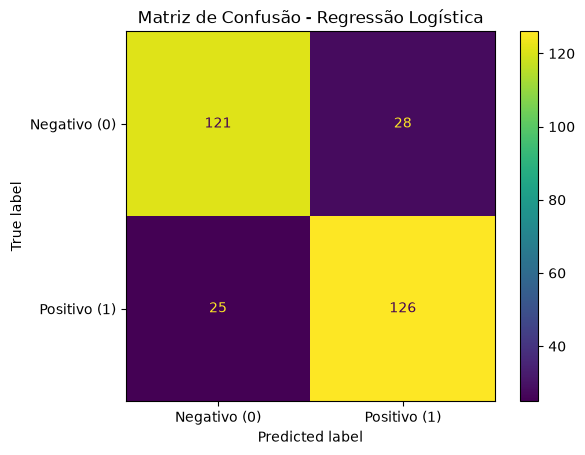

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=test_metrics["confusion_matrix"],
    display_labels=["Negativo (0)", "Positivo (1)"],
).plot()

plt.title("Matriz de Confusão - Regressão Logística")
plt.show()

In [29]:
comparison = pd.DataFrame(
    {
        "real": y_test.values,
        "previsto": y_test_pred,
    }
)

comparison.head(20)

,real,previsto
0,1,1
1,1,0
2,0,0
3,0,1
4,0,0
5,1,1
6,1,1
7,1,0
8,1,1
9,1,0


In [30]:
probabilities = pd.DataFrame(
    {
        "real": y_test.values,
        "previsto": y_test_pred,
        "probabilidade_negativo": y_test_proba[:, 0],
        "probabilidade_positivo": y_test_proba[:, 1],
    }
)

probabilities.head(10)

,real,previsto,probabilidade_negativo,probabilidade_positivo
0,1,1,0.000193,0.999807
1,1,0,0.641065,0.358935
2,0,0,0.896226,0.103774
3,0,1,0.439307,0.560693
4,0,0,0.946544,0.053456
5,1,1,0.007960,0.992040
6,1,1,0.143224,0.856776
7,1,0,0.851270,0.148730
8,1,1,0.241888,0.758112
9,1,0,0.715626,0.284374


## Conclusão

Foi implementado um modelo de Regressão Logística utilizando os embeddings
gerados pelo modelo `all-MiniLM-L6-v2` como características de entrada.

Os dados foram divididos em três conjuntos:

- 70% para treinamento;
- 15% para validação;
- 15% para teste.

O conjunto de validação foi utilizado para comparar diferentes valores
do parâmetro `C` da Regressão Logística.

Após a escolha da configuração com base na validação, o modelo final foi
treinado utilizando os dados de treinamento e validação e avaliado uma
única vez no conjunto de teste.

A avaliação foi realizada utilizando acurácia, precisão, recall, F1-score
e matriz de confusão.